<a href="https://colab.research.google.com/github/Venkateshpaitwar/Code-Comment-Quality-Analyzer-NLP/blob/main/notebooks/comment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas scikit-learn nltk matplotlib

In [2]:
import pandas as pd

df = pd.read_csv("comments_dataset_cleaned.csv")

print("Dataset size:", df.shape)

df.head()

Dataset size: (1617, 3)


,file,comment,clean_comment
0,/content/pandas/pandas/core/internals/construc...,# and a subsequent `astype` will not already r...,and a subsequent astype will not already resul...
1,/content/pandas/pandas/tests/util/test_assert_...,# Do not ignore index.,do not ignore index
2,/content/pandas/pandas/tests/tools/test_to_dat...,# Match Timestamp behavior in disallowing non-...,match timestamp behavior in disallowing nonrou...
3,/content/pandas/pandas/core/internals/construc...,# TODO: is that an issue with numpy?,todo is that an issue with numpy
4,/content/pandas/pandas/core/arrays/datetimelik...,# All of the functions implemented here are or...,all of the functions implemented here are ordi...


In [3]:
def label_comment(text):

    text = text.lower()

    if "todo" in text or "fixme" in text:
        return "TODO"

    elif "debug" in text or "print" in text:
        return "DEBUG"

    elif "return" in text or "param" in text:
        return "DOCSTRING"

    else:
        return "EXPLANATION"

In [4]:
df["label"] = df["clean_comment"].apply(label_comment)

df.head()

,file,comment,clean_comment,label
0,/content/pandas/pandas/core/internals/construc...,# and a subsequent `astype` will not already r...,and a subsequent astype will not already resul...,EXPLANATION
1,/content/pandas/pandas/tests/util/test_assert_...,# Do not ignore index.,do not ignore index,EXPLANATION
2,/content/pandas/pandas/tests/tools/test_to_dat...,# Match Timestamp behavior in disallowing non-...,match timestamp behavior in disallowing nonrou...,EXPLANATION
3,/content/pandas/pandas/core/internals/construc...,# TODO: is that an issue with numpy?,todo is that an issue with numpy,TODO
4,/content/pandas/pandas/core/arrays/datetimelik...,# All of the functions implemented here are or...,all of the functions implemented here are ordi...,EXPLANATION


In [5]:
df["label"].value_counts()

,count
label,
EXPLANATION,1540
TODO,40
DOCSTRING,36
DEBUG,1


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=3000)

X = vectorizer.fit_transform(df["clean_comment"])
y = df["label"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [10]:
y_pred = model.predict(X_test)

In [11]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   DOCSTRING       0.00      0.00      0.00         9
 EXPLANATION       0.95      1.00      0.97       307
        TODO       0.00      0.00      0.00         8

    accuracy                           0.95       324
   macro avg       0.32      0.33      0.32       324
weighted avg       0.90      0.95      0.92       324



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
test_comment = ["todo fix authentication bug"]

vec = vectorizer.transform(test_comment)

prediction = model.predict(vec)

print("Predicted label:", prediction[0])

Predicted label: EXPLANATION


In [13]:
!pip install textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 25.6 MB/s eta 0:00:00


In [14]:
import textstat

In [15]:
def comment_quality_score(text):

    length_score = min(len(text.split()) / 10, 1)

    readability_score = textstat.flesch_reading_ease(text) / 100

    readability_score = max(0, min(readability_score, 1))

    quality = (length_score * 0.5) + (readability_score * 0.5)

    return round(quality, 2)

In [16]:
df["quality_score"] = df["clean_comment"].apply(comment_quality_score)

df.head()

,file,comment,clean_comment,label,quality_score
0,/content/pandas/pandas/core/internals/construc...,# and a subsequent `astype` will not already r...,and a subsequent astype will not already resul...,EXPLANATION,0.82
1,/content/pandas/pandas/tests/util/test_assert_...,# Do not ignore index.,do not ignore index,EXPLANATION,0.58
2,/content/pandas/pandas/tests/tools/test_to_dat...,# Match Timestamp behavior in disallowing non-...,match timestamp behavior in disallowing nonrou...,EXPLANATION,0.60
3,/content/pandas/pandas/core/internals/construc...,# TODO: is that an issue with numpy?,todo is that an issue with numpy,TODO,0.80
4,/content/pandas/pandas/core/arrays/datetimelik...,# All of the functions implemented here are or...,all of the functions implemented here are ordi...,EXPLANATION,0.82


In [17]:
def quality_label(score):

    if score < 0.4:
        return "LOW"

    elif score < 0.7:
        return "MEDIUM"

    else:
        return "HIGH"

In [18]:
df["quality_level"] = df["quality_score"].apply(quality_label)

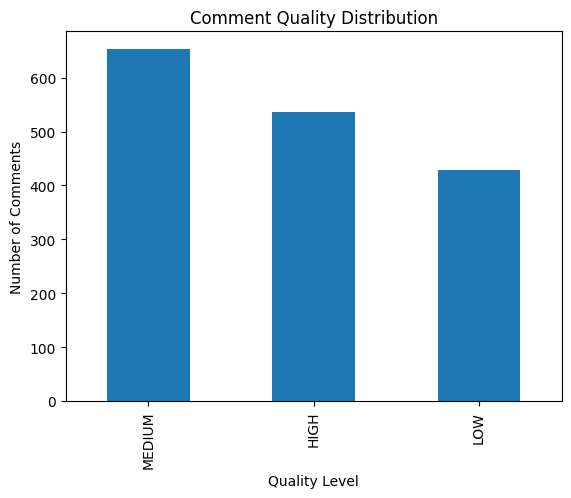

In [19]:
import matplotlib.pyplot as plt

df["quality_level"].value_counts().plot(kind="bar")

plt.title("Comment Quality Distribution")

plt.xlabel("Quality Level")

plt.ylabel("Number of Comments")

plt.show()

In [20]:
comment = "initialize user authentication session"

score = comment_quality_score(comment)

print("Quality Score:", score)
print("Quality Level:", quality_label(score))

Quality Score: 0.2
Quality Level: LOW


In [21]:
df.to_csv("comment_analysis_results.csv", index=False)

print("Analysis results saved")

Analysis results saved
